In [1]:
!pip install lightgbm xgboost optuna shap tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 613.9/613.9 kB 41.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.impute import KNNImputer
from sklearn.ensemble import VotingRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
import optuna
import shap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Collab Uploads/merged_crop_data.csv")

In [4]:
df.drop(columns=['YEAR_x', 'YEAR_y'], inplace=True, errors='ignore')
nasa_cols = ['humidity', 'rainfall_nasa', 'temperature']
imputer   = KNNImputer(n_neighbors=5)
df[nasa_cols] = imputer.fit_transform(df[nasa_cols])

In [5]:
df['Yield'] = np.log1p(df['Yield'])

In [6]:
def estimate_ndvi(season, annual_rainfall):
    base_ndvi = {
        'kharif':     0.65,
        'rabi':       0.55,
        'whole year': 0.70,
        'summer':     0.45,
        'autumn':     0.60
    }
    season_key      = str(season).lower().strip()
    ndvi            = base_ndvi.get(season_key, 0.55)
    rainfall_factor = min(annual_rainfall / 3000, 0.2)
    return round(min(ndvi + rainfall_factor, 1.0), 3)

df['NDVI'] = df.apply(lambda row: estimate_ndvi(row['Season'], row['Annual_Rainfall']), axis=1)

In [7]:
le_crop   = LabelEncoder()
le_season = LabelEncoder()
le_state  = LabelEncoder()

df['Crop']   = le_crop.fit_transform(df['Crop'].str.strip())
df['Season'] = le_season.fit_transform(df['Season'].str.strip())
df['State']  = le_state.fit_transform(df['State'].str.strip())

In [8]:
features = [
    'Crop', 'Crop_Year', 'Season', 'State', 'Area',
    'Annual_Rainfall', 'Fertilizer', 'Pesticide',
    'N', 'P', 'K', 'ph',
    'humidity', 'rainfall_nasa', 'temperature',
    'NDVI'
]

X = df[features]
y = df['Yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth':     trial.suggest_int('max_depth', 3, 10),
        'num_leaves':    trial.suggest_int('num_leaves', 20, 100),
        'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best R2 :", study.best_value)

Best Params: {'n_estimators': 497, 'learning_rate': 0.15753220059641487, 'max_depth': 9, 'num_leaves': 38}
Best R2 : 0.9786956932317045


In [10]:
best = study.best_params

lgb_model = lgb.LGBMRegressor(
    n_estimators  = best['n_estimators'],
    learning_rate = best['learning_rate'],
    max_depth     = best['max_depth'],
    num_leaves    = best['num_leaves'],
    verbose       = -1
)

xgb_model = XGBRegressor(
    n_estimators  = best['n_estimators'],
    learning_rate = best['learning_rate'],
    max_depth     = best['max_depth'],
    verbosity     = 0
)

ensemble = VotingRegressor([
    ('lgb', lgb_model),
    ('xgb', xgb_model)
])

ensemble.fit(X_train, y_train)

preds_real  = np.expm1(ensemble.predict(X_test))
y_test_real = np.expm1(y_test)

print(f"Ensemble R2  : {r2_score(y_test_real, preds_real):.4f}")
print(f"Ensemble MAE : {mean_absolute_error(y_test_real, preds_real):.4f}")

Ensemble R2  : 0.9695
Ensemble MAE : 76.6376


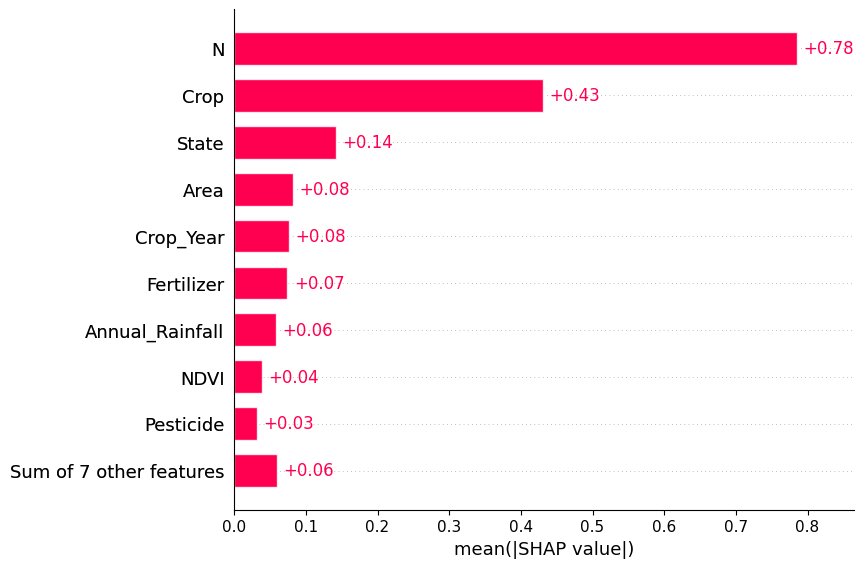


Top Factori s : N (negatively)
Advice : Nitrogen is most critical. Maintain optimal N levels.


In [11]:
lgb_model.fit(X_train, y_train)

explainer   = shap.Explainer(lgb_model)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

shap_advice = {
    'N':               'Nitrogen is most critical. Maintain optimal N levels.',
    'Crop':            'Crop selection heavily impacts yield.',
    'State':           'Your region climate plays a significant role.',
    'Fertilizer':      'Adjust fertilizer for better yield.',
    'Annual_Rainfall': 'Low rainfall detected. Consider irrigation.',
    'NDVI':            'Vegetation health is affecting yield.',
    'temperature':     'Temperature anomaly detected in your region.',
    'humidity':        'Humidity levels are impacting crop health.'
}

sample_shap = shap_values[0].values
sorted_idx  = np.argsort(np.abs(sample_shap))[::-1]
top_feature = features[sorted_idx[0]]
top_value   = sample_shap[sorted_idx[0]]

direction = "positively" if top_value > 0 else "negatively"
advice    = shap_advice.get(top_feature, f"{top_feature} is the top factor.")

print(f"\nTop Factori s : {top_feature} ({direction})")
print(f"Advice : {advice}")

In [12]:
def predict_with_uncertainty(model, X_input, n_iterations=100):
    preds = []
    for _ in range(n_iterations):
        noise       = np.random.normal(0, 0.05, X_input.shape)
        noisy_input = X_input + noise
        pred        = model.predict(noisy_input)[0]
        preds.append(np.expm1(pred))

    lower = np.percentile(preds, 5)
    upper = np.percentile(preds, 95)
    mean  = np.mean(preds)
    width = upper - lower

    if width < 50:
        risk = "Low Risk"
    elif width < 150:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    return {
        "predicted_yield": round(mean, 2),
        "lower_bound":     round(lower, 2),
        "upper_bound":     round(upper, 2),
        "confidence":      "90%",
        "risk_level":      risk
    }

sample = X_test.iloc[0:1]
result = predict_with_uncertainty(lgb_model, sample)
print("Prediction Results are :")
for k, v in result.items():
    print(f"   {k}: {v}")

Prediction Results are :
   predicted_yield: 1.01
   lower_bound: 0.75
   upper_bound: 1.19
   confidence: 90%
   risk_level: Low Risk


In [13]:
yearly_yield = df.groupby('Crop_Year')['Yield'].mean().reset_index()
yearly_yield = yearly_yield.sort_values('Crop_Year')

scaler = MinMaxScaler()
scaled = scaler.fit_transform(yearly_yield[['Yield']])

def create_sequences(data, seq_len=3):
    X_s, y_s = [], []
    for i in range(len(data) - seq_len):
        X_s.append(data[i:i+seq_len])
        y_s.append(data[i+seq_len])
    return np.array(X_s), np.array(y_s)

X_lstm, y_lstm = create_sequences(scaled, seq_len=3)

split       = int(len(X_lstm) * 0.8)
X_train_l   = X_lstm[:split]
X_test_l    = X_lstm[split:]
y_train_l   = y_lstm[:split]

lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(3, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_l, y_train_l, epochs=50, batch_size=4, verbose=0)

lstm_preds      = lstm_model.predict(X_test_l)
lstm_preds_real = scaler.inverse_transform(lstm_preds)

print("Predicted yield trend:", np.expm1(lstm_preds_real.flatten()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Predicted yield trend: [5.7688212 5.68386   5.625109  5.689929  5.7478337]


In [14]:
joblib.dump(ensemble,  'crop_ensemble_model.pkl')
joblib.dump(lgb_model, 'crop_lgb_model.pkl')
joblib.dump(le_crop,   'le_crop.pkl')
joblib.dump(le_season, 'le_season.pkl')
joblib.dump(le_state,  'le_state.pkl')
joblib.dump(features,  'features.pkl')
lstm_model.save('lstm_model.h5')